In [ ]:
import numpy as np
import pickle
import os
import time
import sys

# Caminho absoluto para a pasta vendorizada (raiz do projeto)
root_path = os.path.abspath(os.path.join("..", "..", "third_party", "mlquantify_0.1.11"))
sys.path.insert(0, root_path)

from meta._classes import QuaDapt

def gerar_distribuicoes_moss(
    n_samples,
    n_prevalences,
    n_merges,
    n_curves,
    save_path
):
    """
    Gera um dicionário de distribuições sintéticas usando MoSS da versão vendorizada,
    salva em um pickle único e mede tempo de execução bloco a bloco.
    """

    alphas = np.linspace(0.01, 0.99, n_prevalences)
    merges = np.linspace(0.0, 1.0, n_merges)

    synthetic_distributions = {}
    total = len(alphas) * len(merges)
    count = 0

    print(f"\n🚀 Gerando arquivo: {save_path}")
    print(f"Configuração:")
    print(f"  n_samples     = {n_samples:,}")
    print(f"  n_prevalences = {n_prevalences}")
    print(f"  n_merges      = {n_merges}")
    print(f"  n_curves      = {n_curves}")
    print(f"  Total de combinações (alpha × merge): {total}\n")

    start_global = time.perf_counter()
    last_times = []  # para estimar tempo restante

    for alpha in alphas:
        for merge in merges:
            start = time.perf_counter()  # início do bloco

            curves = []
            for _ in range(n_curves):
                # === CHAMADA AO MoSS DA VERSÃO VENDORIZADA ===
                scores = QuaDapt.MoSS(n_samples, alpha, merge)
                syn_scores = np.concatenate([scores[scores[:, 2] == 1][:, :2],
                                             scores[scores[:, 2] == 0][:, :2]])
                curves.append(syn_scores)

            synthetic_distributions[(round(alpha, 4), round(merge, 4))] = curves

            # ======================
            # Estatísticas do bloco
            # ======================
            block_time = time.perf_counter() - start
            last_times.append(block_time)

            count += 1

            if count % 5 == 0 or count == total:
                avg = np.mean(last_times)
                remaining = (total - count) * avg
                print(
                    f"[{count}/{total}] "
                    f"Último bloco: {block_time:6.2f}s | "
                    f"Tempo médio/bloco: {avg:6.2f}s | "
                    f"Restante estimado: {remaining/60:6.1f} min"
                )

    # Salvar arquivo único
    with open(save_path, "wb") as f:
        pickle.dump(synthetic_distributions, f, protocol=pickle.HIGHEST_PROTOCOL)

    total_runtime = time.perf_counter() - start_global

    print("\n✔ Finalizado e salvo em:")
    print(f"  {save_path}")
    print(f"⏱ Tempo total: {total_runtime/60:,.2f} minutos\n")

    return synthetic_distributions


# ===========================================================
# =============== CONFIGURAÇÕES DESEJADAS ===================
# ===========================================================

# Ultra pesado
MASSIVE_CONFIG = dict(
    n_samples=10_000,
    n_prevalences=40,
    n_merges=40,
    n_curves=100,
    save_path="moss_outputs/moss_GIGANTE.pkl"
)

# Leve
LIGHT_CONFIG = dict(
    n_samples=100,
    n_prevalences=15,
    n_merges=15,
    n_curves=20,
    save_path="moss_outputs/moss_LEVE.pkl"
)


# ===========================================================
# ===================== EXECUÇÃO ============================
# ===========================================================

if __name__ == "__main__":
    os.makedirs("moss_outputs", exist_ok=True)

    print("\n====================================")
    print("      GERANDO ARQUIVO LEVE")
    print("====================================")
    gerar_distribuicoes_moss(**LIGHT_CONFIG)

    print("\n====================================")
    print("   GERANDO ARQUIVO EXTREMAMENTE GRANDE")
    print("   ATENÇÃO: pode consumir centenas de GB")
    print("====================================")

    gerar_distribuicoes_moss(**MASSIVE_CONFIG)

    print("\n🏁 TUDO FINALIZADO.")

In [12]:
import numpy as np
import pandas as pd
import os
import pickle
import warnings
import time
from scipy.stats import skew, kurtosis, entropy
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")

# =================================================
# ================ FEATURE EXTRACTION =============
# =================================================

FEATURE_ORDER = [
    'mean', 'var', 'skew', 'kurt',
    'q10', 'q25', 'q50', 'q75', 'q90',
    'entropy'
]

def extract_features(scores):
    scores = np.ravel(scores)

    features = {
        'mean': np.mean(scores),
        'var': np.var(scores),
        'skew': skew(scores),
        'kurt': kurtosis(scores),
        'q10': np.quantile(scores, 0.1),
        'q25': np.quantile(scores, 0.25),
        'q50': np.quantile(scores, 0.5),
        'q75': np.quantile(scores, 0.75),
        'q90': np.quantile(scores, 0.9)
    }

    hist, _ = np.histogram(scores, bins=20, density=True)
    hist = hist + 1e-12
    features['entropy'] = entropy(hist)

    return np.array([features[k] for k in FEATURE_ORDER])


# =================================================
# ============== PROTOCOLO APP ====================
# =================================================

def generate_artificial_prevalences(n_dim, n_prev=19, n_iter=1):
    if n_dim != 2:
        raise NotImplementedError("Apenas binário por enquanto.")

    prevalences = np.linspace(0.05, 0.95, n_prev)
    combos = [[1-p, p] for p in prevalences]
    return combos * n_iter


def get_indexes_with_prevalence(y, prevalence, batch_size):
    pos_idx = np.where(y == 1)[0]
    neg_idx = np.where(y == 0)[0]

    n_pos = int(batch_size * prevalence[1])
    n_neg = batch_size - n_pos

    pos_sel = np.random.choice(pos_idx, size=n_pos, replace=True)
    neg_sel = np.random.choice(neg_idx, size=n_neg, replace=True)

    idx = np.concatenate([pos_sel, neg_sel])
    np.random.shuffle(idx)
    return idx


class APP:
    def __init__(self, batch_size, n_prevalences, repeats=1, random_state=None):
        self.batch_size = batch_size if isinstance(batch_size, list) else [batch_size]
        self.n_prevalences = n_prevalences
        self.repeats = repeats
        self.random_state = random_state
        if random_state is not None:
            np.random.seed(random_state)

    def split(self, X, y):
        n_dim = len(np.unique(y))
        for batch_size in self.batch_size:
            prevalences = generate_artificial_prevalences(
                n_dim, self.n_prevalences, self.repeats
            )
            for prev in prevalences:
                idx = get_indexes_with_prevalence(y, prev, batch_size)
                yield idx, prev


# =================================================
# ============== REGRESSOR (Treino) ===============
# =================================================

def treinar_regressor_a_partir_do_pkl(pkl_path):
    with open(pkl_path, "rb") as f:
        synthetic_distributions = pickle.load(f)

    X_features, y_labels = [], []

    for key, curves in synthetic_distributions.items():
        all_scores = np.vstack(curves)[:, 0]
        feats = extract_features(all_scores)

        X_features.append(feats)
        y_labels.append(key[0] if isinstance(key, tuple) else key)

    X_features = np.vstack(X_features)
    y_labels = np.array(y_labels)

    reg = RandomForestRegressor(n_estimators=300, random_state=42)
    reg.fit(X_features, y_labels)
    return reg


# =================================================
# =========== CARREGAR DATASET CSV ================
# =================================================

def carregar_dataset_csv(path_csv):
    """
    Espera datasets no formato:

        dataset.csv => contém features + coluna 'y'
    """
    df = pd.read_csv(path_csv)

    # Detecta coluna alvo
    if "y" in df.columns:
        y = df["y"].values
        X = df.drop(columns=["y"]).values
    else:
        # Assume que a última coluna é o rótulo
        y = df.iloc[:, -1].values
        X = df.iloc[:, :-1].values

    # Se multiclass, reduz para binário (maior classe vira 1)
    if len(np.unique(y)) > 2:
        y = (y == np.max(y)).astype(int)

    return X, y


# =================================================
# ================ AVALIAÇÃO APP ==================
# =================================================

def avaliar_regressor_no_dataset_csv(nome_dataset, regressor, app_protocol, root="/var/new_homes/julio/mestrado/mestrado-dyssyn/datasets/binary"):
    path_csv = os.path.join(root, nome_dataset)

    X, y = carregar_dataset_csv(path_csv)

    X = StandardScaler().fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.5, random_state=42, stratify=y
    )

    clf = RandomForestClassifier(n_estimators=300, random_state=42)
    clf.fit(X_train, y_train)

    erros = []

    for idx, prev in app_protocol.split(X_test, y_test):
        X_batch, y_batch = X_test[idx], y_test[idx]
        scores = clf.predict_proba(X_batch)[:, 1]
        feats = extract_features(scores).reshape(1, -1)

        pred_prev = regressor.predict(feats)[0]
        real_prev = np.mean(y_batch)

        erros.append(abs(real_prev - pred_prev))

    return np.mean(erros)


# =================================================
# ================ LOOP PRINCIPAL =================
# =================================================

moss_folder = "/var/new_homes/julio/mestrado/mestrado-dyssyn/datasets/moss"

pkls = [
    os.path.join(moss_folder, f)
    for f in os.listdir(moss_folder)
    if f.endswith(".pkl")
]

datasets_root = "/var/new_homes/julio/mestrado/mestrado-dyssyn/datasets/binary"

datasets = sorted([
    f for f in os.listdir(datasets_root)
    if f.endswith(".csv")
])

print(f"🔍 Encontrados {len(datasets)} datasets CSV em {datasets_root}")

app = APP(batch_size=100, n_prevalences=19, repeats=2, random_state=42)

resultados = []

for pkl in pkls:
    print(f"\n===============================")
    print(f"Treinando regressor com PKL: {pkl}")
    print(f"===============================")

    reg = treinar_regressor_a_partir_do_pkl(pkl)
    pkl_name = os.path.basename(pkl)

    for ds in datasets:
        try:
            print(f"→ Avaliando regressor no dataset {ds} ...")
            erro_medio = avaliar_regressor_no_dataset_csv(ds, reg, app_protocol=app)

            resultados.append({
                "pkl_name": pkl_name,
                "dataset": ds,
                "erro_medio_regressor": erro_medio
            })

        except Exception as e:
            print(f"❌ Erro no dataset {ds}: {e}")

df_final = pd.DataFrame(resultados)
df_final.to_csv("resultados_regressor_por_pkl.csv", index=False)

print("\n===== RESULTADOS SALVOS =====")
print("📄 resultados_regressor_por_pkl.csv")

🔍 Encontrados 119 datasets CSV em /var/new_homes/julio/mestrado/mestrado-dyssyn/datasets/binary

Treinando regressor com PKL: /var/new_homes/julio/mestrado/mestrado-dyssyn/datasets/moss/moss_GIGANTE.pkl
→ Avaliando regressor no dataset 1460_banana.csv ...
→ Avaliando regressor no dataset 1462_banknote-authentication.csv ...
→ Avaliando regressor no dataset 1466_cardiotocography.csv ...
→ Avaliando regressor no dataset 1475_first-order-theorem-proving.csv ...
→ Avaliando regressor no dataset 1479_hill-valley.csv ...
→ Avaliando regressor no dataset 1485_madelon.csv ...
→ Avaliando regressor no dataset 1489_phoneme.csv ...
→ Avaliando regressor no dataset 1494_qsar-biodeg.csv ...
→ Avaliando regressor no dataset 1496_ringnorm.csv ...
→ Avaliando regressor no dataset 1497_wall-robot-navigation.csv ...
→ Avaliando regressor no dataset 1504_steel-plates-fault.csv ...
→ Avaliando regressor no dataset 1507_twonorm.csv ...
→ Avaliando regressor no dataset 1526_wall-robot-navigation.csv ...
→ A

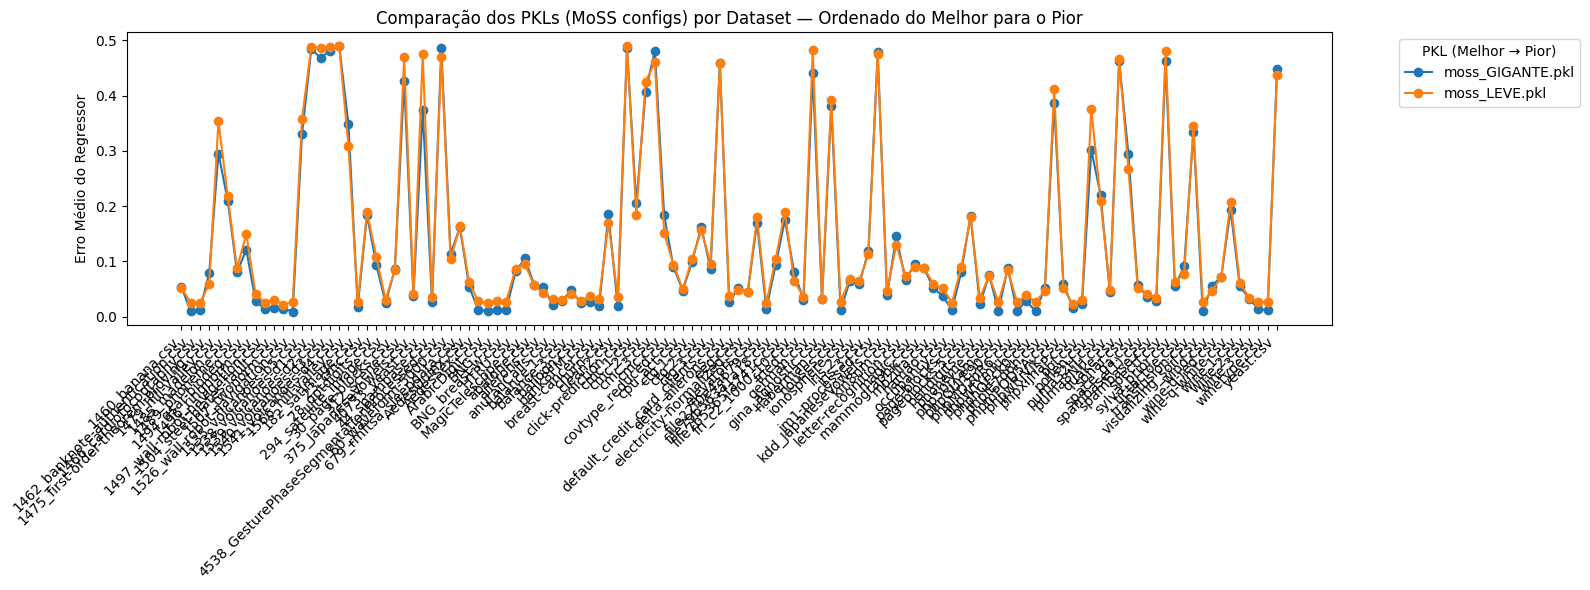

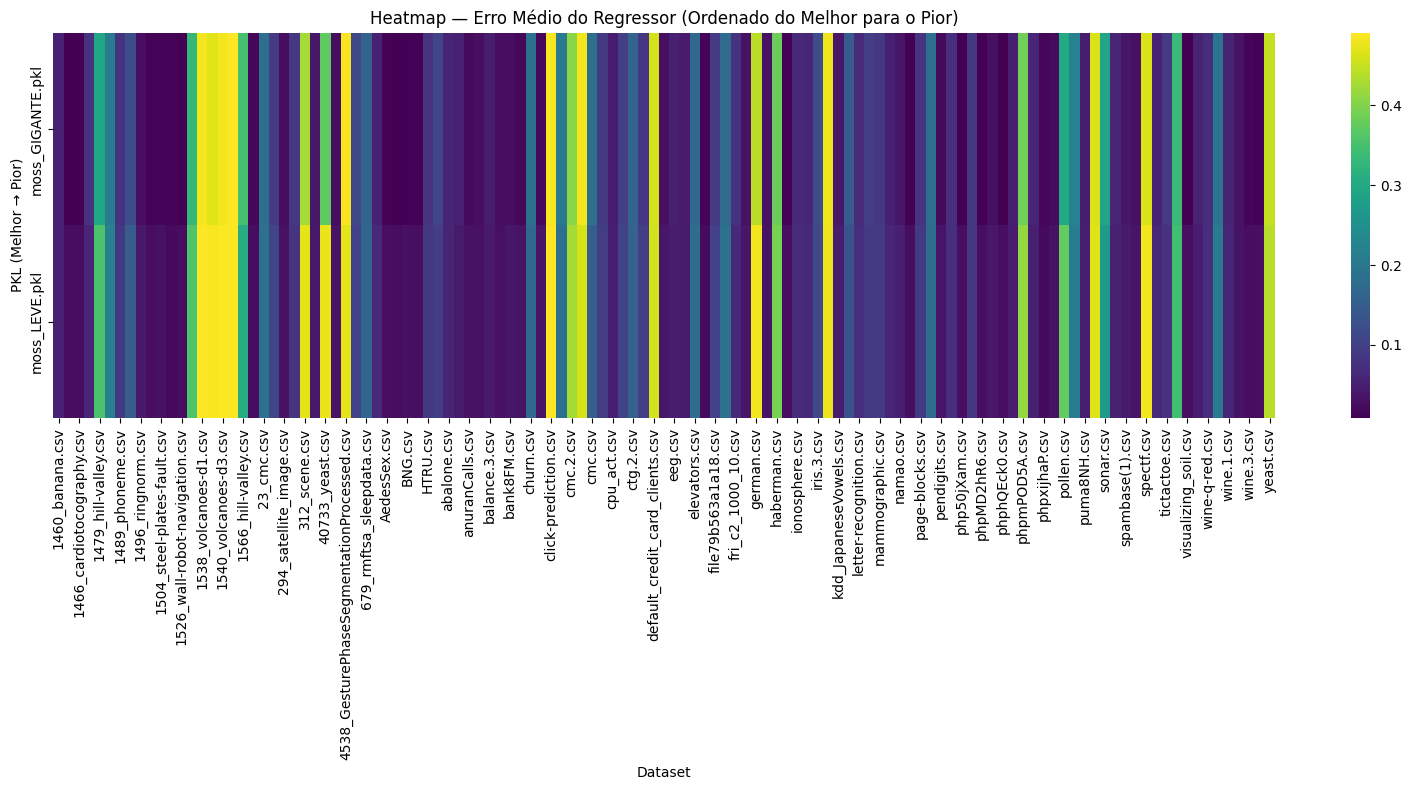

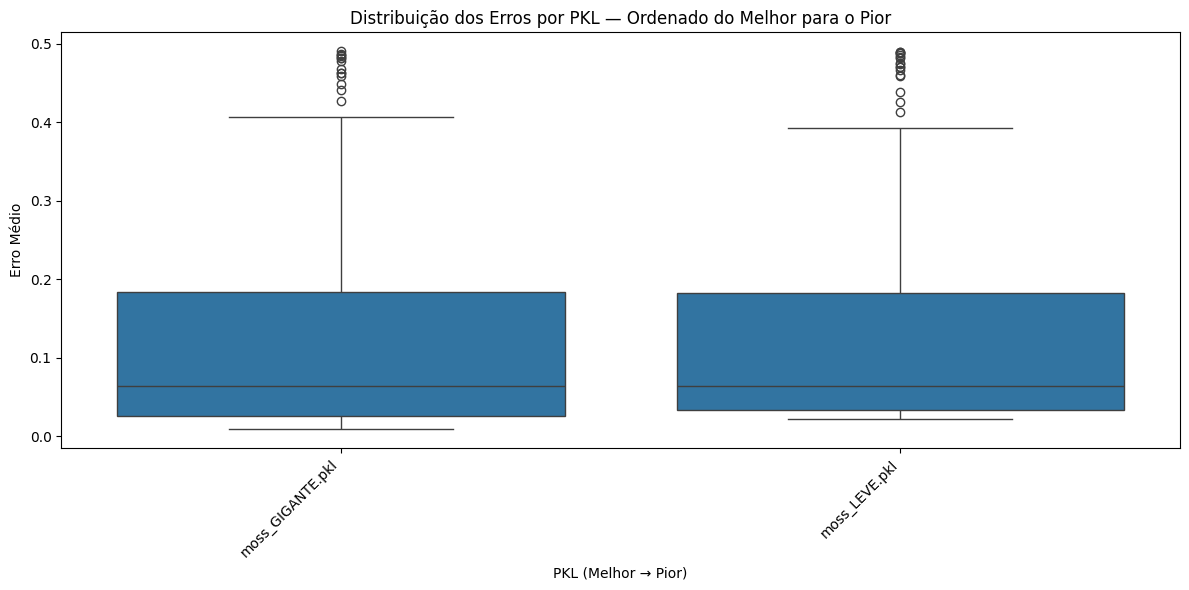

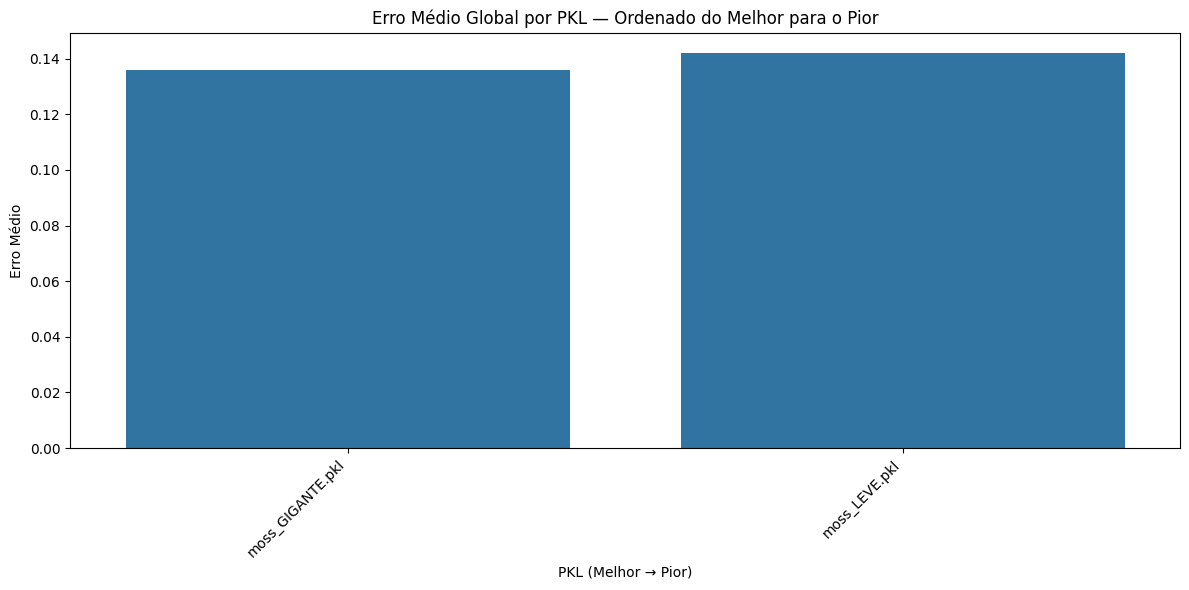

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------------------
# Carregar resultados
# -----------------------------------------------------------
df = pd.read_csv("resultados_regressor_por_pkl.csv")

# Ordenar datasets pelo nome
df["dataset"] = df["dataset"].astype(str)
datasets_ordenados = sorted(df["dataset"].unique())
df["dataset"] = pd.Categorical(df["dataset"], categories=datasets_ordenados, ordered=True)

# -----------------------------------------------------------
# Ordenar PKLs do melhor (menor erro) para o pior (maior erro)
# -----------------------------------------------------------
df_media = df.groupby("pkl_name")["erro_medio_regressor"].mean().reset_index()
df_media = df_media.sort_values("erro_medio_regressor")  # ordenação aqui
pkls_ordenados = df_media["pkl_name"].tolist()

# Garanti que df respeite essa ordem
df["pkl_name"] = pd.Categorical(df["pkl_name"], categories=pkls_ordenados, ordered=True)

# -----------------------------------------------------------
# Gráfico de Linhas (1 linha por PKL) — ordenado do melhor → pior
# -----------------------------------------------------------
plt.figure(figsize=(16, 6))
for pkl in pkls_ordenados:
    df_p = df[df["pkl_name"] == pkl].sort_values("dataset")
    plt.plot(df_p["dataset"], df_p["erro_medio_regressor"], marker="o", label=pkl)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Erro Médio do Regressor")
plt.title("Comparação dos PKLs (MoSS configs) por Dataset — Ordenado do Melhor para o Pior")
plt.legend(title="PKL (Melhor → Pior)", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# -----------------------------------------------------------
# Heatmap PKL × Dataset (erro) — ordenado do melhor → pior
# -----------------------------------------------------------
pivot = df.pivot(index="pkl_name", columns="dataset", values="erro_medio_regressor")
pivot = pivot.loc[pkls_ordenados]  # aplica ordenação

plt.figure(figsize=(16, 8))
sns.heatmap(pivot, cmap="viridis", annot=False)
plt.title("Heatmap — Erro Médio do Regressor (Ordenado do Melhor para o Pior)")
plt.xlabel("Dataset")
plt.ylabel("PKL (Melhor → Pior)")
plt.tight_layout()
plt.show()

# -----------------------------------------------------------
# Boxplot: Distribuição de Erros por PKL — ordenado do melhor → pior
# -----------------------------------------------------------
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="pkl_name", y="erro_medio_regressor", order=pkls_ordenados)
plt.xticks(rotation=45, ha="right")
plt.title("Distribuição dos Erros por PKL — Ordenado do Melhor para o Pior")
plt.ylabel("Erro Médio")
plt.xlabel("PKL (Melhor → Pior)")
plt.tight_layout()
plt.show()

# -----------------------------------------------------------
# Gráfico de Barras: Erro Médio Global por PKL — ordenado
# -----------------------------------------------------------
plt.figure(figsize=(12, 6))
sns.barplot(data=df_media, x="pkl_name", y="erro_medio_regressor", order=pkls_ordenados)
plt.xticks(rotation=45, ha="right")
plt.title("Erro Médio Global por PKL — Ordenado do Melhor para o Pior")
plt.ylabel("Erro Médio")
plt.xlabel("PKL (Melhor → Pior)")
plt.tight_layout()
plt.show()

In [17]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# -----------------------------------------------------------
# Carregar resultados
# -----------------------------------------------------------
df = pd.read_csv("resultados_regressor_por_pkl.csv")

# Ordenar datasets pelo nome
df["dataset"] = df["dataset"].astype(str)
datasets_ordenados = sorted(df["dataset"].unique())
df["dataset"] = pd.Categorical(df["dataset"], categories=datasets_ordenados, ordered=True)

# -----------------------------------------------------------
# Ordenar PKLs do melhor (menor erro) para o pior
# -----------------------------------------------------------
df_media = df.groupby("pkl_name")["erro_medio_regressor"].mean().reset_index()
df_media = df_media.sort_values("erro_medio_regressor")
pkls_ordenados = df_media["pkl_name"].tolist()

df["pkl_name"] = pd.Categorical(df["pkl_name"], categories=pkls_ordenados, ordered=True)

# -----------------------------------------------------------
# Gráfico de Linhas (1 linha por PKL)
# -----------------------------------------------------------
fig = go.Figure()

for pkl in pkls_ordenados:
    df_p = df[df["pkl_name"] == pkl].sort_values("dataset")
    fig.add_trace(go.Scatter(
        x=df_p["dataset"],
        y=df_p["erro_medio_regressor"],
        mode="lines+markers",
        name=pkl
    ))

fig.update_layout(
    title="Comparação dos PKLs (MoSS configs) por Dataset — Ordenado do Melhor para o Pior",
    xaxis_title="Dataset",
    yaxis_title="Erro Médio do Regressor",
    width=1100,
    height=450
)

fig.show()

# -----------------------------------------------------------
# Heatmap PKL × Dataset (erro)
# -----------------------------------------------------------
pivot = df.pivot(index="pkl_name", columns="dataset", values="erro_medio_regressor")
pivot = pivot.loc[pkls_ordenados]  # garanto a ordem

fig = px.imshow(
    pivot,
    color_continuous_scale="viridis",
    aspect="auto",
    labels=dict(color="Erro Médio"),
)

fig.update_layout(
    title="Heatmap — Erro Médio do Regressor (Ordenado do Melhor para o Pior)",
    width=1200,
    height=700
)

fig.show()

# -----------------------------------------------------------
# Boxplot: Distribuição dos erros por PKL
# -----------------------------------------------------------
fig = px.box(
    df,
    x="pkl_name",
    y="erro_medio_regressor",
    category_orders={"pkl_name": pkls_ordenados},
    title="Distribuição dos Erros por PKL — Ordenado do Melhor para o Pior"
)

fig.update_layout(
    xaxis_title="PKL (Melhor → Pior)",
    yaxis_title="Erro Médio",
    width=1200,
    height=500
)

fig.show()

# -----------------------------------------------------------
# Barras: Erro Médio Global por PKL
# -----------------------------------------------------------
fig = px.bar(
    df_media,
    x="pkl_name",
    y="erro_medio_regressor",
    category_orders={"pkl_name": pkls_ordenados},
    title="Erro Médio Global por PKL — Ordenado do Melhor para o Pior"
)

fig.update_layout(
    xaxis_title="PKL (Melhor → Pior)",
    yaxis_title="Erro Médio",
    width=1100,
    height=500
)

fig.show()


In [1]:
import numpy as np
import pandas as pd
import os
import pickle
import warnings
import time
from scipy.stats import skew, kurtosis, entropy
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from mlquantify.likelihood import EMQ

warnings.filterwarnings("ignore")

# =================================================
# ============ FUNÇÃO HELLINGER MANUAL =============
# =================================================

def hellinger_distance(p, q):
    """
    p e q: histogramas normalizados (somando 1)
    """
    p = p / (p.sum() + 1e-12)
    q = q / (q.sum() + 1e-12)
    return (1 / np.sqrt(2)) * np.sqrt(np.sum((np.sqrt(p) - np.sqrt(q))**2))


# =================================================
# ================ FEATURE EXTRACTION =============
# =================================================

FEATURE_ORDER = [
    'mean', 'var', 'skew', 'kurt',
    'q10', 'q25', 'q50', 'q75', 'q90',
    'entropy'
]

def extract_features(scores):
    scores = np.ravel(scores)

    features = {
        'mean': np.mean(scores),
        'var': np.var(scores),
        'skew': skew(scores),
        'kurt': kurtosis(scores),
        'q10': np.quantile(scores, 0.1),
        'q25': np.quantile(scores, 0.25),
        'q50': np.quantile(scores, 0.5),
        'q75': np.quantile(scores, 0.75),
        'q90': np.quantile(scores, 0.9)
    }

    hist, _ = np.histogram(scores, bins=20, density=True)
    hist = hist + 1e-12
    features['entropy'] = entropy(hist)

    return np.array([features[k] for k in FEATURE_ORDER])


# =================================================
# ============== PROTOCOLO APP ====================
# =================================================

def generate_artificial_prevalences(n_dim, n_prev=19, n_iter=1):
    if n_dim != 2:
        raise NotImplementedError("Apenas binário por enquanto.")

    prevalences = np.linspace(0.05, 0.95, n_prev)
    combos = [[1-p, p] for p in prevalences]
    return combos * n_iter


def get_indexes_with_prevalence(y, prevalence, batch_size):
    pos_idx = np.where(y == 1)[0]
    neg_idx = np.where(y == 0)[0]

    n_pos = int(batch_size * prevalence[1])
    n_neg = batch_size - n_pos

    pos_sel = np.random.choice(pos_idx, size=n_pos, replace=True)
    neg_sel = np.random.choice(neg_idx, size=n_neg, replace=True)

    idx = np.concatenate([pos_sel, neg_sel])
    np.random.shuffle(idx)
    return idx


class APP:
    def __init__(self, batch_size, n_prevalences, repeats=1, random_state=None):
        self.batch_size = batch_size if isinstance(batch_size, list) else [batch_size]
        self.n_prevalences = n_prevalences
        self.repeats = repeats
        self.random_state = random_state
        if random_state is not None:
            np.random.seed(random_state)

    def split(self, X, y):
        n_dim = len(np.unique(y))
        for batch_size in self.batch_size:
            prevalences = generate_artificial_prevalences(
                n_dim, self.n_prevalences, self.repeats
            )
            for prev in prevalences:
                idx = get_indexes_with_prevalence(y, prev, batch_size)
                yield idx, prev


# =================================================
# =========== CARREGAR DATASET CSV ================
# =================================================

def carregar_dataset_csv(path_csv):
    df = pd.read_csv(path_csv)

    if "y" in df.columns:
        y = df["y"].values
        X = df.drop(columns=["y"]).values
    else:
        y = df.iloc[:, -1].values
        X = df.iloc[:, :-1].values

    if len(np.unique(y)) > 2:
        y = (y == np.max(y)).astype(int)

    return X, y


# =================================================
# ============ QUANTIFICADORES CLÁSSICOS ==========
# =================================================

def CC(preds):
    return np.mean(preds)

def ACC(preds, y_train, clf, X_train, threshold=0.5):

    # 1. Probabilidades do treino
    train_scores = clf.predict_proba(X_train)[:,1]

    # 2. Predições binárias com threshold
    y_pred_train = (train_scores > threshold).astype(int)

    # 3. Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_train, y_pred_train).ravel()

    # 4. TPR e FPR
    tpr = tp / (tp + fn + 1e-12)
    fpr = fp / (fp + tn + 1e-12)

    # 5. CC do batch
    cc_prev = np.mean(preds > threshold)

    # 6. Ajuste
    adjusted = (cc_prev - fpr) / (tpr - fpr + 1e-12)

    return float(np.clip(adjusted, 0, 1))

def EMQ_quantifier(preds, y_train, tol=1e-4, max_iter=100):
    priors = np.array([1 - np.mean(y_train), np.mean(y_train)])  # [p(0), p(1)]
    posteriors = np.vstack([1 - preds, preds]).T  # shape (n_samples, 2)

    qs, _ = EMQ.EM(
        posteriors=posteriors,
        priors=priors,
        tolerance=tol,
        max_iter=max_iter
    )

    # retorna prevalência da classe positiva
    return float(qs[1])


def find_t50_threshold(y_train, train_scores, n_thresh=200):
    thresholds = np.linspace(0, 1, n_thresh)
    best_tau = 0.5
    best_diff = 1e9

    for t in thresholds:
        y_pred = (train_scores >= t).astype(int)
        tp = np.sum((y_pred == 1) & (y_train == 1))
        fn = np.sum((y_pred == 0) & (y_train == 1))

        if tp + fn == 0:
            continue

        tpr = tp / (tp + fn)
        diff = abs(tpr - 0.5)

        if diff < best_diff:
            best_diff = diff
            best_tau = t

    return best_tau

def T50(preds, threshold):
    return np.mean(preds >= threshold)

def MAX(preds, y_train_scores, y_train, n_thresholds=101):
    """
    Implementação do método MAX (Forman 2005)
    Maximiza (TPR - FPR) no conjunto de treino.
    preds: scores do batch
    y_train_scores: scores do conjunto de treino
    y_train: rótulos do conjunto de treino
    """
    thresholds = np.linspace(0, 1, n_thresholds)
    best_j = -999
    best_t = 0.5

    for t in thresholds:
        y_pred_train = (y_train_scores >= t).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_train, y_pred_train).ravel()
        tpr = tp / (tp + fn + 1e-12)
        fpr = fp / (fp + tn + 1e-12)
        j = tpr - fpr

        if j > best_j:
            best_j = j
            best_t = t

    # aplica o threshold ideal no batch
    return np.mean(preds >= best_t)

def MS(preds):
    return np.median(preds)

def HDy(preds, y_train_scores):
    bins = 20
    h1, _ = np.histogram(preds, bins=bins, range=(0,1), density=True)
    h2, _ = np.histogram(y_train_scores, bins=bins, range=(0,1), density=True)
    h1 += 1e-12
    h2 += 1e-12
    return 1 - hellinger_distance(h1, h2)

# =================================================
# =========== DyS OFICIAL (tipo mlquantify) =======
# =================================================

def dys_distance(h1, h2, measure="topsoe"):
    if measure == "hellinger":
        return hellinger_distance(h1, h2)
    elif measure == "topsoe":
        return np.sum(h1 * np.log((2*h1) / (h1 + h2 + 1e-12)))
    elif measure == "probsymm":
        return np.sum((h1 - h2) ** 2 / (h1 + h2 + 1e-12))
    else:
        raise ValueError("measure inválida")


def DyS(preds, pos_scores, neg_scores, measure="topsoe", bins=20):
    """
    Implementação oficial do método DyS (Dynamic Similarity).
    """
    H_test, _ = np.histogram(preds, bins=bins, range=(0, 1), density=True)
    H_test += 1e-12

    H_pos, _ = np.histogram(pos_scores, bins=bins, range=(0, 1), density=True)
    H_neg, _ = np.histogram(neg_scores, bins=bins, range=(0, 1), density=True)
    H_pos += 1e-12
    H_neg += 1e-12

    # busca ternária de α
    left, right = 0.0, 1.0
    for _ in range(40):
        m1 = left + (right - left) / 3
        m2 = right - (right - left) / 3

        H_mix1 = m1 * H_pos + (1 - m1) * H_neg
        H_mix2 = m2 * H_pos + (1 - m2) * H_neg

        d1 = dys_distance(H_test, H_mix1, measure)
        d2 = dys_distance(H_test, H_mix2, measure)

        if d1 < d2:
            right = m2
        else:
            left = m1

    alpha = (left + right) / 2
    return float(alpha)


# =================================================
# =============== DySyn (heurística) ==============
# =================================================

def DySyn(preds):
    """
    Heurística dinâmica suave e estável.
    """
    p = preds
    m = np.mean(p)

    hist, _ = np.histogram(p, bins=20, range=(0,1), density=True)
    hist += 1e-12
    ent = entropy(hist)

    return float(0.7 * m + 0.3 * (1 - ent))


def SMM(preds, y_train_scores):
    return abs(np.mean(preds) - np.mean(y_train_scores))


# =================================================
# ================ AVALIAÇÃO APP ==================
# =================================================

def avaliar_quantificadores_no_dataset_csv(
    nome_dataset, app_protocol,
    root="/var/new_homes/julio/mestrado/mestrado-dyssyn/datasets/binary"
):
    path_csv = os.path.join(root, nome_dataset)

    X, y = carregar_dataset_csv(path_csv)

    X = StandardScaler().fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.5, random_state=42, stratify=y
    )

    clf = RandomForestClassifier(n_estimators=300, random_state=42)
    clf.fit(X_train, y_train)

    y_train_scores = clf.predict_proba(X_train)[:, 1]

    t50_tau = find_t50_threshold(y_train, y_train_scores)

    resultados = []

    for idx, prev in app_protocol.split(X_test, y_test):
        X_batch, y_batch = X_test[idx], y_test[idx]
        scores = clf.predict_proba(X_batch)[:, 1]

        real_prev = np.mean(y_batch)

        pos_scores = y_train_scores[y_train == 1]
        neg_scores = y_train_scores[y_train == 0]

        q = {
            "CC": CC(scores),
            "ACC": ACC(scores, y_train, clf, X_train),
            "EMQ": EMQ_quantifier(scores, y_train),
            "T50": T50(scores, t50_tau),
            "MAX": MAX(scores, y_train_scores, y_train),
            "MS": MS(scores),
            "HDy": HDy(scores, y_train_scores),
            "SMM": SMM(scores, y_train_scores),
            "DyS": DyS(scores, pos_scores, neg_scores),
            "DySyn": DySyn(scores)  
        }

        resultados.append({
            "real": real_prev,
            **{f"err_{k}": abs(real_prev - q[k]) for k in q},
        })

    df = pd.DataFrame(resultados)
    return df.mean().to_dict()


# =================================================
# ================ LOOP PRINCIPAL =================
# =================================================

datasets_root = "/var/new_homes/julio/mestrado/mestrado-dyssyn/datasets/binary"

datasets = sorted([
    f for f in os.listdir(datasets_root)
    if f.endswith(".csv")
])

print(f"🔍 Encontrados {len(datasets)} datasets CSV em {datasets_root}")

app = APP(batch_size=100, n_prevalences=19, repeats=2, random_state=42)

resultados = []

for ds in datasets:
    try:
        print(f"→ Avaliando no dataset {ds} ...")
        res = avaliar_quantificadores_no_dataset_csv(ds, app_protocol=app)
        res["dataset"] = ds
        resultados.append(res)

    except Exception as e:
        print(f"❌ Erro no dataset {ds}: {e}")

df_final = pd.DataFrame(resultados)
df_final.to_csv("resultados_quantificadores.csv", index=False)

print("\n===== RESULTADOS SALVOS =====")
print("📄 resultados_quantificadores.csv")

🔍 Encontrados 119 datasets CSV em /var/new_homes/julio/mestrado/mestrado-dyssyn/datasets/binary
→ Avaliando no dataset 1460_banana.csv ...
→ Avaliando no dataset 1462_banknote-authentication.csv ...
→ Avaliando no dataset 1466_cardiotocography.csv ...
→ Avaliando no dataset 1475_first-order-theorem-proving.csv ...
→ Avaliando no dataset 1479_hill-valley.csv ...
→ Avaliando no dataset 1485_madelon.csv ...
[warning] the method has reached the maximum number of iterations; it might have not converged
[warning] the method has reached the maximum number of iterations; it might have not converged
[warning] the method has reached the maximum number of iterations; it might have not converged
[warning] the method has reached the maximum number of iterations; it might have not converged
[warning] the method has reached the maximum number of iterations; it might have not converged
[warning] the method has reached the maximum number of iterations; it might have not converged
[warning] the method h

In [22]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# -----------------------------------------------------------
# Carregar resultados
# -----------------------------------------------------------
df_reg = pd.read_csv("resultados_regressor.csv")
df_quant = pd.read_csv("resultados_quantificadores.csv")

# Ordenar datasets
df_reg["dataset"] = df_reg["dataset"].astype(str)
df_quant["dataset"] = df_quant["dataset"].astype(str)

datasets_ordenados = sorted(set(df_reg["dataset"].unique()) | set(df_quant["dataset"].unique()))
df_reg["dataset"] = pd.Categorical(df_reg["dataset"], categories=datasets_ordenados, ordered=True)
df_quant["dataset"] = pd.Categorical(df_quant["dataset"], categories=datasets_ordenados, ordered=True)

# -----------------------------------------------------------
# Preparar dataframe dos quantificadores para formato long
# -----------------------------------------------------------
quant_cols = [c for c in df_quant.columns if c.startswith("err_")]

dfq_long = df_quant.melt(
    id_vars=["dataset"],
    value_vars=quant_cols,
    var_name="method",
    value_name="erro"
)

# Renomear método (tirar o prefixo err_)
dfq_long["method"] = dfq_long["method"].apply(lambda x: x.replace("err_", ""))

# -----------------------------------------------------------
# Preparar regressors para formato long também
# -----------------------------------------------------------
dfr_long = df_reg.rename(columns={"erro_medio_regressor": "erro"})
dfr_long["method"] = dfr_long["pkl_name"]
dfr_long = dfr_long[["dataset", "method", "erro"]]

# -----------------------------------------------------------
# Juntar tudo
# -----------------------------------------------------------
df_all = pd.concat([dfr_long, dfq_long], ignore_index=True)

# Ordenar métodos: regressors primeiro, quantifiers depois
regressors = sorted(df_reg["pkl_name"].unique())
quantifiers = sorted(dfq_long["method"].unique())
method_order = regressors + quantifiers
df_all["method"] = pd.Categorical(df_all["method"], categories=method_order, ordered=True)

# -----------------------------------------------------------
# 1) GRÁFICO INTEGRADO: linhas de regressors + quantifiers
# -----------------------------------------------------------
fig = go.Figure()
for m in method_order:
    df_m = df_all[df_all["method"] == m].sort_values("dataset")
    fig.add_trace(go.Scatter(
        x=df_m["dataset"],
        y=df_m["erro"],
        mode="lines+markers",
        name=m
    ))

fig.update_layout(
    title="Comparação Geral — Regressors (MoSS) + Quantificadores",
    xaxis_title="Dataset",
    yaxis_title="Erro Médio",
    width=1200,
    height=600
)
fig.show()

# -----------------------------------------------------------
# 2) HEATMAP UNIFICADO
# -----------------------------------------------------------
pivot_all = df_all.pivot(index="method", columns="dataset", values="erro")
pivot_all = pivot_all.loc[method_order]

fig = px.imshow(
    pivot_all,
    color_continuous_scale="viridis",
    aspect="auto",
    labels=dict(color="Erro Médio"),
)

fig.update_layout(
    title="Heatmap — Regressors + Quantificadores",
    width=1300,
    height=800
)
fig.show()

# -----------------------------------------------------------
# 3) BOXPLOT UNIFICADO (distribuição dos erros)
# -----------------------------------------------------------
fig = px.box(
    df_all,
    x="method",
    y="erro",
    category_orders={"method": method_order},
    title="Distribuição dos Erros — Regressors + Quantificadores"
)

fig.update_layout(
    xaxis_title="Método",
    yaxis_title="Erro",
    width=1400,
    height=600
)
fig.show()

# -----------------------------------------------------------
# 4) BARRAS COM ERRO MÉDIO GLOBAL
# -----------------------------------------------------------
df_global = df_all.groupby("method")["erro"].mean().reset_index()
df_global = df_global.sort_values("erro")

fig = px.bar(
    df_global,
    x="method",
    y="erro",
    title="Erro Médio Global — Regressors vs Quantificadores"
)

fig.update_layout(
    xaxis_title="Método (Ordenado do Melhor → Pior)",
    yaxis_title="Erro Médio",
    width=1300,
    height=600
)
fig.show()